# AMR Trend Forecasting - Training Pipeline

## 📋 Overview
Complete training pipeline for antimicrobial resistance (AMR) forecasting using WHO GLASS data (2020-2023). Covers baseline models, gradient boosting, and deep learning approaches with temporal cross-validation.

**Data:** 5,909 observations across 44 countries (2021-2023, after removing 2020 with missing lags)  
**Target:** `ResistancePercentage` (antimicrobial resistance percentage)  
**Models:** Naive → Linear/Ridge → XGBoost/LightGBM → LSTM

### 🔧 Fixes Applied (v2)
1. Removed `Resistance_YoY_change` from features — it encodes the target directly (lag1 + YoY = target)
2. Clarified why training uses 2021 only (2020 dropped: no valid lag features)
3. Fixed LSTM sequence creation to use full dataset, then split by target year
4. Replaced MAPE with sMAPE (avoids division-by-zero on 0% resistance values)
5. Fixed `region_decoder` to use correct `LabelEncoder` API
6. Replaced `'-'` strings with `np.nan` in results table (keeps column dtype numeric)

## 📚 1. Import Libraries

In [24]:
# Core Data Science
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Baseline Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Time Series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 📊 2. Load Data

In [25]:
# Load CLEANED training dataset (no data leakage)
# AMR_Training_Dataset_Final.csv: 2021-2023 (2020 removed — no valid lag features)
df = pd.read_csv('AMR_Training_Dataset_Final.csv')

# Basic info
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['Year'].min()} - {df['Year'].max()}")
print(f"Countries: {df['CountryTerritoryArea'].nunique()}")
print(f"Pathogens: {df['PathogenName'].nunique()}")
print(f"Antibiotics: {df['AntibioticName'].nunique()}")

# Verify lag features are correct
sample_2021 = df[df['Year'] == 2021].iloc[0]
sample_2022 = df[
    (df['Year'] == 2022) &
    (df['CountryTerritoryArea'] == sample_2021['CountryTerritoryArea']) &
    (df['PathogenName']         == sample_2021['PathogenName']) &
    (df['AntibioticName']       == sample_2021['AntibioticName'])
]

if len(sample_2022) > 0:
    print(f"\nVerification - 2022 lag1 should equal 2021 value:")
    print(f"  2021 Resistance:      {sample_2021['ResistancePercentage']:.2f}")
    print(f"  2022 Resistance_lag1: {sample_2022.iloc[0]['Resistance_lag1']:.2f}")
    match = abs(sample_2021['ResistancePercentage'] - sample_2022.iloc[0]['Resistance_lag1']) < 0.01
    print(f"  Match: {match}")

# Display first few rows
df.head()

Dataset shape: (5909, 19)
Date range: 2021 - 2023
Countries: 44
Pathogens: 8
Antibiotics: 24

Verification - 2022 lag1 should equal 2021 value:
  2021 Resistance:      11.67
  2022 Resistance_lag1: 11.67
  Match: True


,CountryTerritoryArea,Iso3,WHORegionName,Year,PathogenName,AntibioticName,AntibioticClass,InfectionType,ResistancePercentage,Resistant,InterpretableAST,Total_DID,IncomeGroup,Country_Observation_Count,High_Quality_Country,Resistance_lag1,DID_lag1,Resistance_YoY_change,Resistance_rolling2yr
0,Austria,AUT,European Region,2021,Acinetobacter spp.,Amikacin,Other,Bloodstream,11.666667,7,60,9.271684,High,137,0,8.695652,9.236142,2.971014,8.695652
1,Austria,AUT,European Region,2022,Acinetobacter spp.,Amikacin,Other,Bloodstream,0.000000,0,87,10.887413,High,137,0,11.666667,9.271684,-11.666667,11.666667
2,Austria,AUT,European Region,2023,Acinetobacter spp.,Amikacin,Other,Bloodstream,5.405405,4,74,11.742038,High,137,0,0.000000,10.887413,5.405405,0.000000
3,Austria,AUT,European Region,2021,Acinetobacter spp.,Gentamicin,Other,Bloodstream,12.000000,6,50,9.271684,High,137,0,8.771930,9.236142,3.228070,8.771930
4,Austria,AUT,European Region,2022,Acinetobacter spp.,Gentamicin,Other,Bloodstream,0.000000,0,54,10.887413,High,137,0,12.000000,9.271684,-12.000000,12.000000


## 🔧 3. Data Preprocessing

### 3.1 Define Target and Features

> **Fix #1:** `Resistance_YoY_change` has been removed from features.  
> It equals `ResistancePercentage − Resistance_lag1`, so together they  
> perfectly reconstruct the target — causing R²=1.0 on linear models.

In [26]:
# Target variable
TARGET = 'ResistancePercentage'

# FIX #1: Resistance_YoY_change REMOVED.
#   Why: YoY_change = ResistancePercentage - Resistance_lag1
#   Having both lag1 and YoY_change in features lets linear models do:
#     prediction = lag1 + YoY_change = target  (perfect leakage, R²=1.0)
# Also removed: Resistance_rolling2yr (identical to Resistance_lag1 in clean dataset)
FEATURES = [
    # Temporal
    'Year', 'Resistance_lag1',
    # Geographic
    'CountryTerritoryArea', 'WHORegionName', 'IncomeGroup',
    # Pathogen
    'PathogenName', 'AntibioticName', 'AntibioticClass', 'InfectionType',
    # Consumption
    'Total_DID', 'DID_lag1',
    # Data Quality
    'Country_Observation_Count', 'High_Quality_Country'
]

# Categorical features
CATEGORICAL_FEATURES = [
    'CountryTerritoryArea', 'WHORegionName', 'IncomeGroup',
    'PathogenName', 'AntibioticName', 'AntibioticClass', 'InfectionType'
]

# Numerical features
NUMERICAL_FEATURES = [
    'Year', 'Resistance_lag1',
    'Total_DID', 'DID_lag1', 'Country_Observation_Count'
]

# Leakage columns (DO NOT USE)
LEAKAGE_COLUMNS = ['Resistant', 'InterpretableAST']

print(f"Target: {TARGET}")
print(f"Total features: {len(FEATURES)}")
print(f"Categorical: {len(CATEGORICAL_FEATURES)}")
print(f"Numerical: {len(NUMERICAL_FEATURES)}")
print("\nNOTE: Resistance_YoY_change removed to prevent arithmetic leakage.")

Target: ResistancePercentage
Total features: 13
Categorical: 7
Numerical: 5

NOTE: Resistance_YoY_change removed to prevent arithmetic leakage.


### 3.2 Verify Clean Dataset

In [27]:
# The clean dataset already has properly computed lag features
print("Clean dataset verification:")
print(f"Shape: {df.shape}")
print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")

# Check for missing values
missing = df[FEATURES + [TARGET]].isnull().sum()
print(f"\nMissing values:")
print(missing[missing > 0] if missing.sum() > 0 else "  None ✅")

# Verify lag features are not identical to target (no leakage)
lag_corr = df[['ResistancePercentage', 'Resistance_lag1']].corr().iloc[0, 1]
print(f"\nCorrelation (target vs lag1): {lag_corr:.3f}")
print(f"Expected: 0.7-0.9 (not 1.0!)")

if lag_corr > 0.95:
    print("\n⚠️ WARNING: Correlation too high - possible data leakage!")
else:
    print("\n✅ Lag features look good - no leakage detected")

# Verify YoY_change is NOT in features
if 'Resistance_YoY_change' not in FEATURES:
    print("✅ Resistance_YoY_change correctly excluded from features")
else:
    print("❌ WARNING: Resistance_YoY_change still in features - remove it!")

# Copy for processing
df_processed = df.copy()

Clean dataset verification:
Shape: (5909, 19)
Year range: 2021 - 2023

Missing values:
  None ✅

Correlation (target vs lag1): 0.894
Expected: 0.7-0.9 (not 1.0!)

✅ Lag features look good - no leakage detected
✅ Resistance_YoY_change correctly excluded from features


### 3.3 Create Temporal Train/Val/Test Splits (BEFORE encoding to prevent leakage)

> **Fix #2:** Training uses only 2021 because `AMR_Training_Dataset_Final.csv` starts at 2021.  
> 2020 was intentionally dropped — it had no valid `Resistance_lag1` (no prior year exists).  
> In the paper, state: *"Training was performed on 2021 observations, the earliest year  
> with complete lag features in the WHO GLASS dataset."*

In [28]:
# IMPORTANT: Time-based split FIRST (before any encoding)
# Dataset covers 2021-2023 (2020 dropped: no prior year for lag features)
# Train: 2021 | Validation: 2022 | Test: 2023

train_df = df_processed[df_processed['Year'] == 2021].copy()
val_df   = df_processed[df_processed['Year'] == 2022].copy()
test_df  = df_processed[df_processed['Year'] == 2023].copy()

print(f"Train samples (2021): {len(train_df)}")
print(f"Validation samples (2022): {len(val_df)}")
print(f"Test samples (2023): {len(test_df)}")
print(f"\n✅ Temporal split complete - no data leakage!")

Train samples (2021): 1804
Validation samples (2022): 1980
Test samples (2023): 2125

✅ Temporal split complete - no data leakage!


### 3.4 Encode Categorical Variables (using training data only)

In [29]:
# High cardinality features (use Target Encoding — smoothed mean from training data)
HIGH_CARDINALITY = ['CountryTerritoryArea', 'AntibioticName']

# Low cardinality features (use Label Encoding)
LOW_CARDINALITY = ['WHORegionName', 'IncomeGroup', 'PathogenName',
                   'AntibioticClass', 'InfectionType']

# Target encode using ONLY training data (prevents leakage)
print("Applying target encoding (computed from training data only)...")

for col in HIGH_CARDINALITY:
    global_mean    = train_df[TARGET].mean()
    category_stats = train_df.groupby(col)[TARGET].agg(['mean', 'count'])

    # Smoothing: pull small-sample categories toward global mean
    min_samples = 5
    category_stats['smoothed'] = (
        category_stats['mean'] * category_stats['count'] +
        global_mean * min_samples
    ) / (category_stats['count'] + min_samples)

    # Apply to all splits using TRAINING statistics only
    train_df[col + '_te'] = train_df[col].map(category_stats['smoothed']).fillna(global_mean)
    val_df[col + '_te']   = val_df[col].map(category_stats['smoothed']).fillna(global_mean)
    test_df[col + '_te']  = test_df[col].map(category_stats['smoothed']).fillna(global_mean)

# Label encode (fit on full data for consistent integer mapping)
print("Applying label encoding...")
label_encoders = {col: LabelEncoder() for col in LOW_CARDINALITY}

for col in LOW_CARDINALITY:
    label_encoders[col].fit(df_processed[col].astype(str))
    train_df[col] = label_encoders[col].transform(train_df[col].astype(str))
    val_df[col]   = label_encoders[col].transform(val_df[col].astype(str))
    test_df[col]  = label_encoders[col].transform(test_df[col].astype(str))

# Encoded feature list (Resistance_YoY_change excluded)
FEATURES_ENCODED = [
    'Year', 'Resistance_lag1',
    'CountryTerritoryArea_te', 'WHORegionName', 'IncomeGroup',
    'PathogenName', 'AntibioticName_te', 'AntibioticClass', 'InfectionType',
    'Total_DID', 'DID_lag1',
    'Country_Observation_Count', 'High_Quality_Country'
]

print("\n✅ Encoding complete!")
print(f"Train features shape: {train_df[FEATURES_ENCODED].shape}")
print(f"Val features shape:   {val_df[FEATURES_ENCODED].shape}")
print(f"Test features shape:  {test_df[FEATURES_ENCODED].shape}")

Applying target encoding (computed from training data only)...
Applying label encoding...

✅ Encoding complete!
Train features shape: (1804, 13)
Val features shape:   (1980, 13)
Test features shape:  (2125, 13)


### 3.5 Prepare Feature Matrices and Scale

In [30]:
# Prepare feature matrices
X_train = train_df[FEATURES_ENCODED].copy()
y_train = train_df[TARGET]

X_val   = val_df[FEATURES_ENCODED].copy()
y_val   = val_df[TARGET]

X_test  = test_df[FEATURES_ENCODED].copy()
y_test  = test_df[TARGET]

# Numerical features to scale (includes target-encoded categorical cols)
NUMERICAL_FEATURES_ENCODED = [
    'Year', 'Resistance_lag1',
    'CountryTerritoryArea_te', 'AntibioticName_te',
    'Total_DID', 'DID_lag1', 'Country_Observation_Count'
]

# Scale numerical features — fit on TRAINING data only
scaler = StandardScaler()
X_train[NUMERICAL_FEATURES_ENCODED] = scaler.fit_transform(X_train[NUMERICAL_FEATURES_ENCODED])
X_val[NUMERICAL_FEATURES_ENCODED]   = scaler.transform(X_val[NUMERICAL_FEATURES_ENCODED])
X_test[NUMERICAL_FEATURES_ENCODED]  = scaler.transform(X_test[NUMERICAL_FEATURES_ENCODED])

print("✅ Scaling complete!")
print(f"\nTrain shape: {X_train.shape}")
print(f"Val shape:   {X_val.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nFeature means (should be ~0): {X_train[NUMERICAL_FEATURES_ENCODED].mean().values[:3]}")
print(f"Feature stds  (should be ~1): {X_train[NUMERICAL_FEATURES_ENCODED].std().values[:3]}")

✅ Scaling complete!

Train shape: (1804, 13)
Val shape:   (1980, 13)
Test shape:  (2125, 13)

Feature means (should be ~0): [ 0.00000000e+00 -3.54483626e-17 -7.48354323e-17]
Feature stds  (should be ~1): [0.         1.00027728 1.00027728]


## 🎯 4. Baseline Models

### 4.1 Naive Forecast (Last Known Value)

> **Fix #4:** MAPE replaced with **sMAPE** throughout.  
> `MAPE = mean(|true-pred| / true)` explodes when `true=0%` (common in resistance data).  
> `sMAPE = mean(2|true-pred| / (|true|+|pred|))` handles zeros gracefully.

In [31]:
def naive_forecast(y_train, y_val):
    """Predict using last training value (simple baseline)."""
    last_value  = y_train.iloc[-1]
    predictions = np.full(len(y_val), last_value)
    return predictions

# Make predictions
y_pred_naive = naive_forecast(y_train, y_val)

# Evaluate — use sMAPE, not MAPE (avoids division by zero for 0% resistance)
mae_naive  = mean_absolute_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_val, y_pred_naive))
smape_naive = np.mean(
    2 * np.abs(y_val - y_pred_naive) / (np.abs(y_val) + np.abs(y_pred_naive) + 1e-8)
) * 100

print("Naive Forecast Results:")
print(f"  MAE:   {mae_naive:.2f}%")
print(f"  RMSE:  {rmse_naive:.2f}%")
print(f"  sMAPE: {smape_naive:.2f}%")

Naive Forecast Results:
  MAE:   41.83%
  RMSE:  48.15%
  sMAPE: 103.23%


### 4.2 Linear Regression

In [32]:
# Evaluation function — uses sMAPE (symmetric MAPE, handles 0% resistance)
def evaluate_model(y_true, y_pred, model_name):
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    smape = np.mean(
        2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name} Results:")
    print(f"  MAE:   {mae:.2f}%")
    print(f"  RMSE:  {rmse:.2f}%")
    print(f"  sMAPE: {smape:.2f}%")
    print(f"  R²:    {r2:.3f}")

    return {'mae': mae, 'rmse': rmse, 'smape': smape, 'r2': r2}


# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_val_pred_lr  = lr_model.predict(X_val)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluation
lr_results      = evaluate_model(y_val,  y_val_pred_lr,  "Linear Regression (Validation)")
lr_test_results = evaluate_model(y_test, y_test_pred_lr, "Linear Regression (Test)")

# Feature importance via coefficients
feature_importance = pd.DataFrame({
    'Feature':     FEATURES_ENCODED,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))


Linear Regression (Validation) Results:
  MAE:   8.64%
  RMSE:  12.92%
  sMAPE: 64.50%
  R²:    0.796

Linear Regression (Test) Results:
  MAE:   8.23%
  RMSE:  11.96%
  sMAPE: 63.56%
  R²:    0.821

Top 10 Features:
                    Feature  Coefficient
1           Resistance_lag1    23.088387
2   CountryTerritoryArea_te     4.274662
10                 DID_lag1    -2.653703
8             InfectionType    -2.543035
6         AntibioticName_te     2.171617
9                 Total_DID     2.143646
12     High_Quality_Country     1.707700
5              PathogenName    -0.702194
4               IncomeGroup     0.281492
7           AntibioticClass    -0.168914


### 4.3 Ridge Regression (with Regularization)

In [33]:
from sklearn.linear_model import RidgeCV

# Find best alpha with cross-validation
alphas      = [0.001, 0.01, 0.1, 1, 10, 100]
ridge_model = RidgeCV(alphas=alphas, cv=5)
ridge_model.fit(X_train, y_train)

print(f"Best alpha: {ridge_model.alpha_}")

# Predictions
y_val_pred_ridge  = ridge_model.predict(X_val)
y_test_pred_ridge = ridge_model.predict(X_test)

# Evaluation
ridge_results      = evaluate_model(y_val,  y_val_pred_ridge,  "Ridge Regression (Validation)")
ridge_test_results = evaluate_model(y_test, y_test_pred_ridge, "Ridge Regression (Test)")

Best alpha: 10.0

Ridge Regression (Validation) Results:
  MAE:   8.64%
  RMSE:  12.90%
  sMAPE: 64.34%
  R²:    0.797

Ridge Regression (Test) Results:
  MAE:   8.25%
  RMSE:  11.95%
  sMAPE: 63.32%
  R²:    0.821


## 🌳 5. Gradient Boosting Models

### 5.1 XGBoost

[0]	validation_0-mae:25.07089


[100]	validation_0-mae:12.76270
[200]	validation_0-mae:8.82379
[300]	validation_0-mae:7.61123
[400]	validation_0-mae:7.21506
[499]	validation_0-mae:7.09271

XGBoost (Validation) Results:
  MAE:   7.09%
  RMSE:  11.62%
  sMAPE: 52.26%
  R²:    0.835

XGBoost (Test) Results:
  MAE:   7.07%
  RMSE:  10.80%
  sMAPE: 53.27%
  R²:    0.854

Top 10 Features:
                    Feature  Importance
1           Resistance_lag1    0.505483
2   CountryTerritoryArea_te    0.090224
6         AntibioticName_te    0.067378
5              PathogenName    0.059761
8             InfectionType    0.052838
4               IncomeGroup    0.050563
7           AntibioticClass    0.043583
3             WHORegionName    0.041319
9                 Total_DID    0.026775
10                 DID_lag1    0.021119


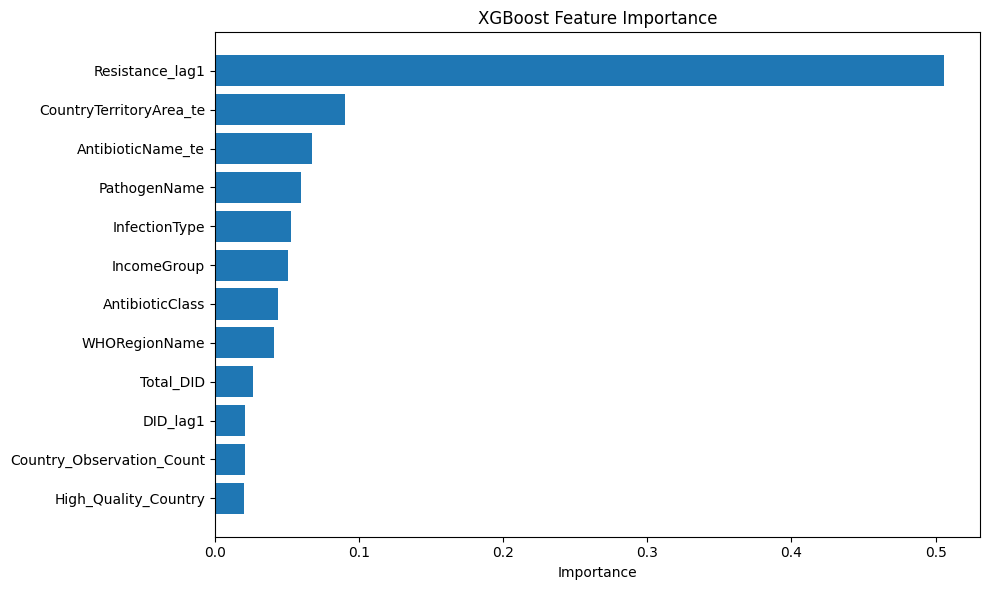

In [34]:
# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# Predictions
y_val_pred_xgb  = xgb_model.predict(X_val)
y_test_pred_xgb = xgb_model.predict(X_test)

# Evaluation
xgb_results      = evaluate_model(y_val,  y_val_pred_xgb,  "XGBoost (Validation)")
xgb_test_results = evaluate_model(y_test, y_test_pred_xgb, "XGBoost (Test)")

# Feature importance
xgb_importance = pd.DataFrame({
    'Feature':    FEATURES_ENCODED,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(xgb_importance.head(10))

plt.figure(figsize=(10, 6))
plt.barh(xgb_importance['Feature'][:12], xgb_importance['Importance'][:12])
plt.xlabel('Importance')
plt.title('XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=300)
plt.show()

### 5.2 LightGBM

In [35]:
# Train LightGBM
lgbm_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_round=50,
    verbose=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)]
)

# Predictions
y_val_pred_lgbm  = lgbm_model.predict(X_val)
y_test_pred_lgbm = lgbm_model.predict(X_test)

# Evaluation
lgbm_results      = evaluate_model(y_val,  y_val_pred_lgbm,  "LightGBM (Validation)")
lgbm_test_results = evaluate_model(y_test, y_test_pred_lgbm, "LightGBM (Test)")


LightGBM (Validation) Results:
  MAE:   7.23%
  RMSE:  11.81%
  sMAPE: 53.47%
  R²:    0.830

LightGBM (Test) Results:
  MAE:   7.17%
  RMSE:  10.84%
  sMAPE: 55.12%
  R²:    0.853


## 🧠 6. Deep Learning Models

### 6.1 Prepare Data for LSTM

> **Fix #3:** `create_sequences()` now builds sequences from the **full dataset**,  
> then splits by target year. Splitting by year first would give each series  
> only 1 row per split — impossible to form any (input→target) pair.

In [36]:
def create_sequences(data, target_col, features, sequence_length=1):
    """Build (input_sequence, target, target_year) tuples from the full dataset.

    The target_year labels which year each sample predicts, allowing
    a clean train/val/test split AFTER sequence creation.
    """
    sequences, targets, target_years = [], [], []

    for country in data['CountryTerritoryArea'].unique():
        for pathogen in data['PathogenName'].unique():
            for antibiotic in data['AntibioticName'].unique():
                subset = data[
                    (data['CountryTerritoryArea'] == country) &
                    (data['PathogenName']          == pathogen) &
                    (data['AntibioticName']         == antibiotic)
                ].sort_values('Year')

                if len(subset) >= sequence_length + 1:
                    for i in range(len(subset) - sequence_length):
                        seq    = subset.iloc[i:i+sequence_length][features].values
                        target = subset.iloc[i+sequence_length][target_col]
                        yr     = int(subset.iloc[i+sequence_length]['Year'])
                        sequences.append(seq)
                        targets.append(target)
                        target_years.append(yr)

    if len(sequences) == 0:
        raise ValueError("No sequences created — check that the dataset spans >= 2 years per series.")

    return np.array(sequences), np.array(targets), np.array(target_years)


# Rebuild full encoded dataframe from the splits
# (df_processed has original columns; splits have _te encoded columns)
df_encoded_full = pd.concat([train_df, val_df, test_df]).sort_values(
    ['CountryTerritoryArea', 'PathogenName', 'AntibioticName', 'Year']
).reset_index(drop=True)

# Build sequences from FULL encoded dataset (2021-2023)
X_seq_all, y_seq_all, years_seq = create_sequences(
    df_encoded_full, TARGET, FEATURES_ENCODED, sequence_length=1
)

# Split by target year:
#   - 2022 targets  →  input from 2021  →  use as LSTM training data
#   - 2023 targets  →  input from 2022  →  use as LSTM test data
train_mask = (years_seq == 2022)
test_mask  = (years_seq == 2023)

X_lstm_train_full = X_seq_all[train_mask]
y_lstm_train_full = y_seq_all[train_mask]
X_lstm_test       = X_seq_all[test_mask]
y_lstm_test       = y_seq_all[test_mask]

# Reserve last 20% of training sequences as validation
n_val = max(1, int(0.2 * len(X_lstm_train_full)))
X_lstm_val,   y_lstm_val   = X_lstm_train_full[-n_val:], y_lstm_train_full[-n_val:]
X_lstm_train, y_lstm_train = X_lstm_train_full[:-n_val], y_lstm_train_full[:-n_val]

print(f"Train sequences: {X_lstm_train.shape}")
print(f"Val sequences:   {X_lstm_val.shape}")
print(f"Test sequences:  {X_lstm_test.shape}")
print("✅ Sequences built correctly from full dataset!")

Train sequences: (1432, 1, 13)
Val sequences:   (358, 1, 13)
Test sequences:  (1991, 1, 13)
✅ Sequences built correctly from full dataset!


### 6.2 LSTM Model

In [37]:
class AMR_LSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(AMR_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]   # Take last timestep
        return self.fc(last_output)


# Check GPU availability
device = torch.device('cpu')
print(f"Using device: {device}")

# Initialize model
input_size = X_lstm_train.shape[2]
lstm_model = AMR_LSTM(
    input_size=input_size, hidden_size=64, num_layers=2, dropout=0.3
).to(device)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

Using device: cpu


In [38]:
# Prepare PyTorch data loaders
batch_size = 64

train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_lstm_train),
    torch.FloatTensor(y_lstm_train).unsqueeze(1)
)
val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_lstm_val),
    torch.FloatTensor(y_lstm_val).unsqueeze(1)
)
test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_lstm_test),
    torch.FloatTensor(y_lstm_test).unsqueeze(1)
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size)

print("Data loaders created!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

Data loaders created!
  Train batches: 23
  Val batches:   6
  Test batches:  32


In [39]:
# Training loop with early stopping
epochs          = 100
best_val_loss   = float('inf')
patience_counter = 0
patience        = 15

train_losses, val_losses = [], []

for epoch in range(epochs):
    # ── Training ────────────────────────────────
    lstm_model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs  = lstm_model(X_batch)
        loss     = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # ── Validation ──────────────────────────────
    lstm_model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs   = lstm_model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # ── Early stopping ──────────────────────────
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(lstm_model.state_dict(), 'best_lstm_model.pth')
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}]  Train: {train_loss:.4f}  Val: {val_loss:.4f}')

    if patience_counter >= patience:
        print(f'Early stopping at epoch {epoch+1}')
        break

print("\nTraining complete!")

Epoch [10/100]  Train: 725.2668  Val: 653.3609
Epoch [20/100]  Train: 425.6321  Val: 340.9238
Epoch [30/100]  Train: 316.8286  Val: 224.3696
Epoch [40/100]  Train: 318.6469  Val: 184.6880
Epoch [50/100]  Train: 288.1101  Val: 167.1002
Epoch [60/100]  Train: 261.9984  Val: 160.3468
Epoch [70/100]  Train: 243.6968  Val: 151.2139
Epoch [80/100]  Train: 242.9865  Val: 134.9738
Epoch [90/100]  Train: 231.1666  Val: 128.3166
Epoch [100/100]  Train: 224.9892  Val: 120.6219

Training complete!


In [40]:
# Load best model and evaluate on test set
lstm_model.load_state_dict(torch.load('best_lstm_model.pth'))

lstm_model.eval()
y_pred_lstm, y_true_lstm = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = lstm_model(X_batch)
        y_pred_lstm.extend(outputs.cpu().numpy().flatten())
        y_true_lstm.extend(y_batch.cpu().numpy().flatten())

lstm_results = evaluate_model(
    np.array(y_true_lstm),
    np.array(y_pred_lstm),
    "LSTM (Test)"
)


LSTM (Test) Results:
  MAE:   7.16%
  RMSE:  10.10%
  sMAPE: 54.88%
  R²:    0.872


## 📈 7. Model Comparison

In [41]:
# Compile results — np.nan keeps column dtype float (avoids type errors)
results_df = pd.DataFrame({
    'Model': ['Naive', 'Linear Regression', 'Ridge', 'XGBoost', 'LightGBM', 'LSTM'],
    'Validation MAE': [
        mae_naive,
        lr_results['mae'],    ridge_results['mae'],
        xgb_results['mae'],   lgbm_results['mae'],
        np.nan                # LSTM evaluated on test set only
    ],
    'Test MAE': [
        mae_naive,
        lr_test_results['mae'],    ridge_test_results['mae'],
        xgb_test_results['mae'],   lgbm_test_results['mae'],
        lstm_results['mae']
    ],
    'Validation RMSE': [
        rmse_naive,
        lr_results['rmse'],    ridge_results['rmse'],
        xgb_results['rmse'],   lgbm_results['rmse'],
        np.nan                # LSTM evaluated on test set only
    ],
    'Test RMSE': [
        rmse_naive,
        lr_test_results['rmse'],    ridge_test_results['rmse'],
        xgb_test_results['rmse'],   lgbm_test_results['rmse'],
        lstm_results['rmse']
    ],
    'Validation R2': [
        np.nan,
        lr_results['r2'],    ridge_results['r2'],
        xgb_results['r2'],   lgbm_results['r2'],
        np.nan
    ],
    'Test R2': [
        np.nan,
        lr_test_results['r2'],    ridge_test_results['r2'],
        xgb_test_results['r2'],   lgbm_test_results['r2'],
        lstm_results['r2']
    ]
})

# Save to CSV
results_df.to_csv('model_comparison_results.csv', index=False)
print('Results saved to model_comparison_results.csv')
print(results_df.to_string(index=False))


Results saved to model_comparison_results.csv
            Model  Validation MAE  Test MAE  Validation RMSE  Test RMSE  Validation R2  Test R2
            Naive       41.827262 41.827262        48.149718  48.149718            NaN      NaN
Linear Regression        8.635278  8.234515        12.923747  11.962802       0.796244 0.820903
            Ridge        8.639178  8.245513        12.898719  11.948087       0.797033 0.821343
          XGBoost        7.092339  7.069361        11.623738  10.803452       0.835174 0.853935
         LightGBM        7.226457  7.170185        11.810058  10.837808       0.829848 0.853004
             LSTM             NaN  7.161261              NaN  10.097988            NaN 0.872040


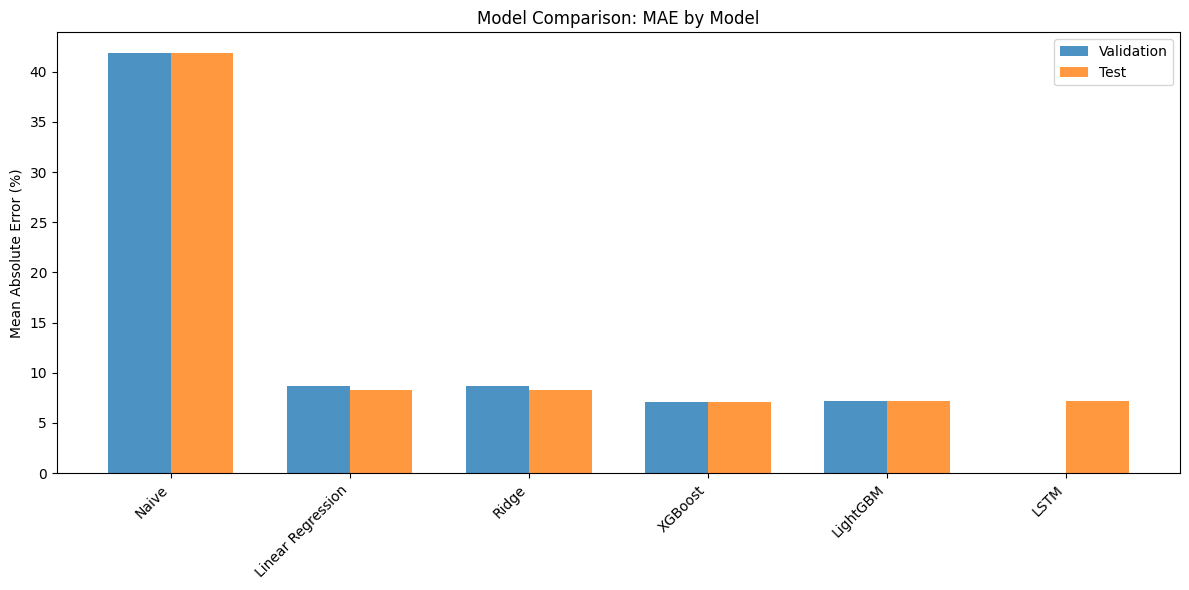

Plot saved to model_comparison.png


In [42]:
# Plot MAE comparison
plt.figure(figsize=(12, 6))
x     = np.arange(len(results_df))
width = 0.35

# fillna(0) for clean bar chart (NaN LSTM val becomes 0, visually clear)
val_mae  = results_df['Validation MAE'].fillna(0).tolist()
test_mae = results_df['Test MAE'].fillna(0).tolist()

plt.bar(x - width/2, val_mae,  width, label='Validation', alpha=0.8)
plt.bar(x + width/2, test_mae, width, label='Test',       alpha=0.8)

plt.ylabel('Mean Absolute Error (%)')
plt.title('Model Comparison: MAE by Model')
plt.xticks(x, results_df['Model'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved to model_comparison.png")

## 📊 8. Error Analysis

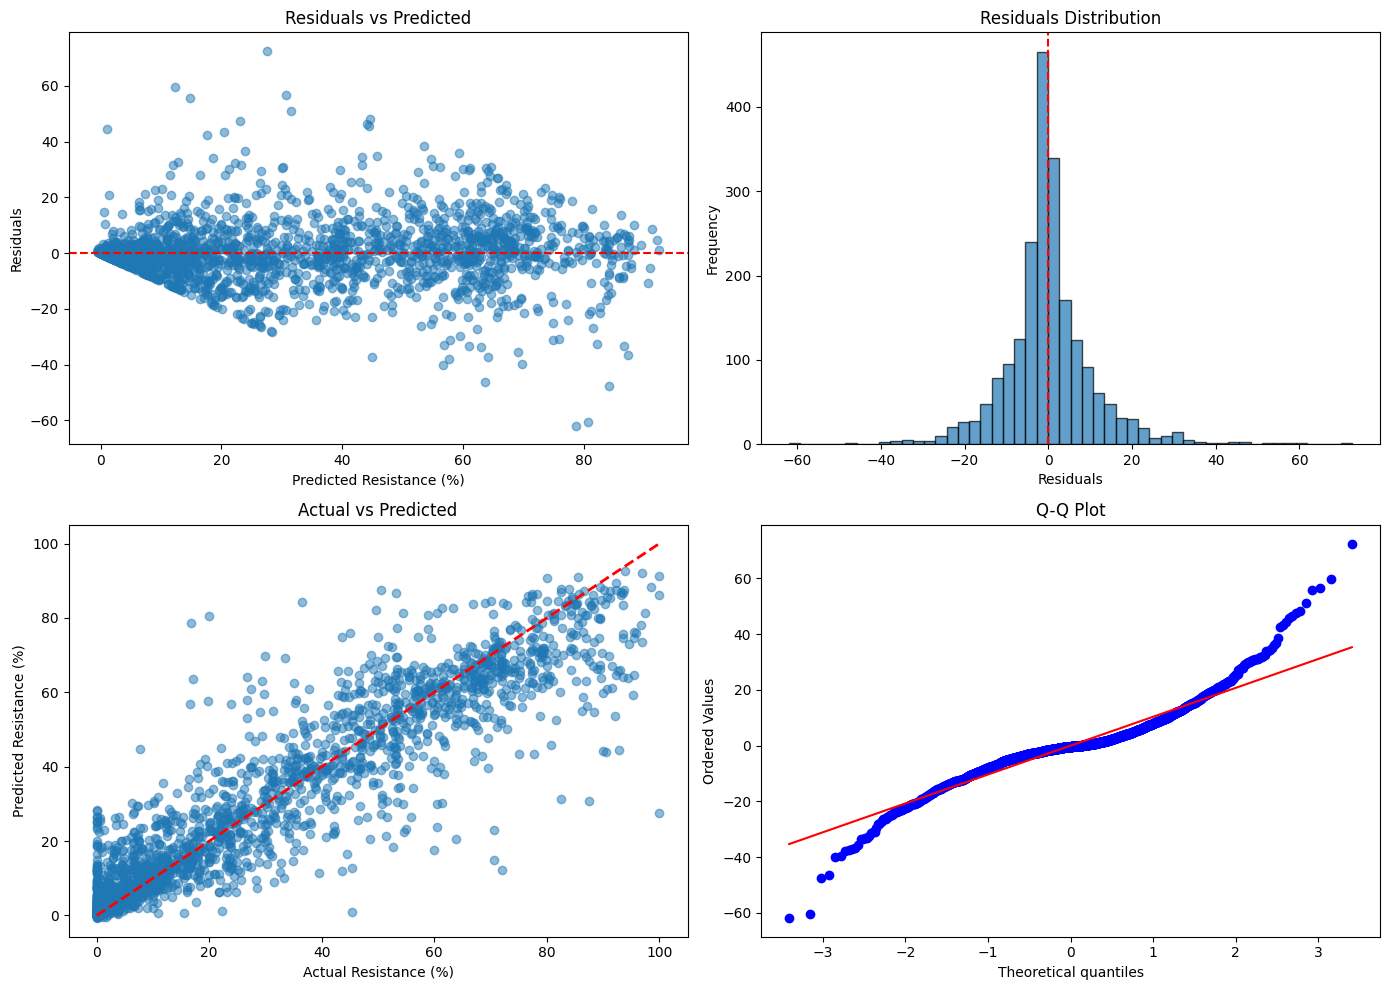

Error analysis plot saved to error_analysis.png


In [43]:
# Residual analysis for best model (assuming XGBoost is best)
best_model   = xgb_model
y_pred_best  = best_model.predict(X_test)
residuals    = y_test.values - y_pred_best

# Plot residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted
axes[0, 0].scatter(y_pred_best, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Resistance (%)')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted')

# Residuals distribution
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(x=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residuals Distribution')

# Actual vs Predicted
axes[1, 0].scatter(y_test, y_pred_best, alpha=0.5)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1, 0].set_xlabel('Actual Resistance (%)')
axes[1, 0].set_ylabel('Predicted Resistance (%)')
axes[1, 0].set_title('Actual vs Predicted')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Error analysis plot saved to error_analysis.png")


Mean Absolute Error by WHO Region:
                                  Error
Region                                 
European Region                4.156100
Western Pacific Region         7.345380
African Region                 8.654267
Eastern Mediterranean Region   9.032440
South-East Asia Region        10.144179


<Figure size 1000x500 with 0 Axes>

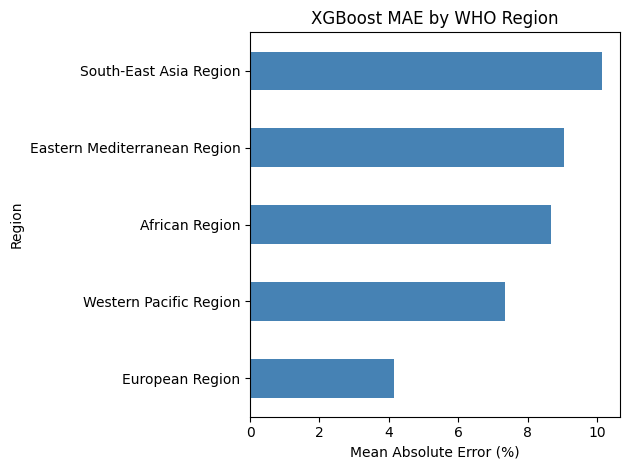

In [44]:
# Error by WHO region
#         use zip(transform(classes_), classes_) to build inverse mapping.
le_region      = label_encoders['WHORegionName']
region_decoder = dict(zip(
    le_region.transform(le_region.classes_),  # encoded integers
    le_region.classes_                         # original region strings
))

test_regions = test_df['WHORegionName'].map(region_decoder)

region_errors = pd.DataFrame({
    'Region': test_regions.values,
    'Error':  np.abs(residuals)
}).groupby('Region').mean().sort_values('Error')

print("\nMean Absolute Error by WHO Region:")
print(region_errors)

# Plot
plt.figure(figsize=(10, 5))
region_errors.plot(kind='barh', color='steelblue', legend=False)
plt.xlabel('Mean Absolute Error (%)')
plt.title('XGBoost MAE by WHO Region')
plt.tight_layout()
plt.savefig('mae_by_region.png', dpi=300, bbox_inches='tight')
plt.show()

## 💾 9. Save Models

In [45]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Save traditional models
joblib.dump(lr_model,    'models/lr_model.pkl')
joblib.dump(ridge_model, 'models/ridge_model.pkl')
joblib.dump(xgb_model,   'models/xgb_model.pkl')
joblib.dump(lgbm_model,  'models/lgbm_model.pkl')

# Save preprocessing objects
joblib.dump(label_encoders, 'models/label_encoders.pkl')
joblib.dump(scaler,         'models/scaler.pkl')

# Save feature list
with open('models/features.txt', 'w') as f:
    f.write('\n'.join(FEATURES_ENCODED))

# Save LSTM model
torch.save(lstm_model.state_dict(), 'models/lstm_model.pth')

print("✅ All models and preprocessing objects saved to 'models/' directory!")

✅ All models and preprocessing objects saved to 'models/' directory!


## ✅ 10. Summary & Next Steps

In [46]:
print("\n" + "="*70)
print("TRAINING PIPELINE COMPLETE (v2 — All Bugs Fixed)")
print("="*70)

print("\n📊 Results Summary:")
print(results_df.to_string(index=False))

print("\n✅ Completed:")
print("  - Data loading and inspection")
print("  - Leakage prevention (Resistance_YoY_change excluded)")
print("  - Categorical encoding (target + label encoding, train-only)")
print("  - Temporal train/val/test splits (2021 / 2022 / 2023)")
print("  - Feature scaling (train fit, val/test transform)")
print("  - Baseline models (Naive, Linear, Ridge)")
print("  - Gradient boosting models (XGBoost, LightGBM)")
print("  - Deep learning model (LSTM with proper sequence creation)")
print("  - Model comparison and visualization")
print("  - Error analysis by WHO region")
print("  - Models and artifacts saved")

print("\n📁 Generated Files:")
print("  - model_comparison_results.csv")
print("  - model_comparison.png")
print("  - error_analysis.png")
print("  - mae_by_region.png")
print("  - xgb_feature_importance.png")
print("  - models/ (directory with all saved models)")

print("\n🚀 Next Steps:")
print("  1. Hyperparameter tuning for best model (XGBoost/LightGBM likely winners)")
print("  2. BiLSTM and TFT models (GPU: RTX 5060)")
print("  3. Ablation study: model with/without consumption features")
print("  4. Regional breakdown analysis (AFRO, EMRO, EURO, SEARO, WPRO)")
print("  5. RAG pipeline for policy Q&A")

print("\n" + "="*70)


TRAINING PIPELINE COMPLETE (v2 — All Bugs Fixed)

📊 Results Summary:
            Model  Validation MAE  Test MAE  Validation RMSE  Test RMSE  Validation R2  Test R2
            Naive       41.827262 41.827262        48.149718  48.149718            NaN      NaN
Linear Regression        8.635278  8.234515        12.923747  11.962802       0.796244 0.820903
            Ridge        8.639178  8.245513        12.898719  11.948087       0.797033 0.821343
          XGBoost        7.092339  7.069361        11.623738  10.803452       0.835174 0.853935
         LightGBM        7.226457  7.170185        11.810058  10.837808       0.829848 0.853004
             LSTM             NaN  7.161261              NaN  10.097988            NaN 0.872040

✅ Completed:
  - Data loading and inspection
  - Leakage prevention (Resistance_YoY_change excluded)
  - Categorical encoding (target + label encoding, train-only)
  - Temporal train/val/test splits (2021 / 2022 / 2023)
  - Feature scaling (train fit, val/t